## Cafe sales analysis

We Got this Dataset from kaggle.This is my first project on Data analysis and fortunatly this dataset consist of messy data that make me improve my data cleaning skills.In this dataset we have Transaction_ID, Item,Quantity, 'Price_Per_Unit, Total_Spent, Payment_Method, Location & Transaction_Date.
we are finding

1. Highest revenue genrated item
2. Most sold item
3. least sale month
4. highest total_spent



In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

Using Colab cache for faster access to the 'cafe-sales-dirty-data-for-cleaning-training' dataset.


In [158]:
df = pd.read_csv(file_path)
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [159]:
df.shape

(10000, 8)

### DATA Inspection


In [160]:
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_9226047,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [161]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [162]:
df.isnull().sum()

,0
Transaction ID,0
Item,333
Quantity,138
Price Per Unit,179
Total Spent,173
Payment Method,2579
Location,3265
Transaction Date,159


In [163]:
df['Item'].unique().tolist()

['Coffee',
 'Cake',
 'Cookie',
 'Salad',
 'Smoothie',
 'UNKNOWN',
 'Sandwich',
 nan,
 'ERROR',
 'Juice',
 'Tea']

In [164]:
df['Transaction ID'].duplicated().sum()

np.int64(0)

#### hence There are no duplicate rows are there.

## Data Cleaning
To prepare the data for analysis, we perform the following cleaning steps:
- Convert column names to `snake_case`
- Convert object types to appropriate numerical or datetime types
- Handle missing or null values

In [165]:
# converting columns to snake case
df.columns=df.columns.str.replace(" ","_",)
df.columns

Index(['Transaction_ID', 'Item', 'Quantity', 'Price_Per_Unit', 'Total_Spent',
       'Payment_Method', 'Location', 'Transaction_Date'],
      dtype='object')

In [219]:
# Object to Numeric conversion
df['Quantity']=pd.to_numeric(df['Quantity'], errors='coerce')
df['Price_Per_Unit']=pd.to_numeric(df['Price_Per_Unit'], errors='coerce',downcast='float')
df['Total_Spent']=pd.to_numeric(df['Total_Spent'], errors='coerce',downcast='float')

# object to Date conversion
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], errors='coerce')

#### Filling null values

In [167]:
df['Item'].value_counts()

,count
Item,
Juice,1171
Coffee,1165
Salad,1148
Cake,1139
Sandwich,1131
Smoothie,1096
Cookie,1092
Tea,1089
UNKNOWN,344


In [168]:
df[~df['Item'].isin(['UNKNOWN','ERROR'])].groupby('Item')[['Price_Per_Unit']].value_counts() #finding price of each item excluding errors

,,count
Item,Price_Per_Unit,
Cake,3.0,1085
Coffee,2.0,1108
Cookie,1.0,1026
Juice,3.0,1110
Salad,5.0,1082
Sandwich,4.0,1082
Smoothie,4.0,1036
Tea,1.5,1023


In [169]:
price_dict = {
    'Coffee': 2.0,
    'Tea': 1.5,
    'Sandwich': 4.0,
    'Salad': 5.0,
    'Cake': 3.0,
    'Cookie': 1.0,
    'Smoothie': 4.0,
    'Juice': 3.0
}
# Filling the price per unit based on the item
df['Price_Per_Unit'] = df['Price_Per_Unit'].fillna(df['Item'].map(price_dict))

item_dict={
    1.0:'Cookie',
    1.5:'Tea',
    2.0:'Coffee',
    3.0:'Juice',
    4.0:'Sandwich',
    5.0:'Salad'
}

# filling the item based on  the price_per_unit

df['Item'] = df['Item'].replace(["UNKNOWN","ERROR"], np.nan)
df['Item'] = df['Item'].fillna(df['Price_Per_Unit'].map(item_dict))

In [170]:
df['Price_Per_Unit'].isnull().sum()

np.int64(54)

In [171]:
df[df['Item'].isnull()].head(), df[df['Item'].isnull()].shape

(    Transaction_ID Item  Quantity  Price_Per_Unit  Total_Spent  \
 118    TXN_4633784  NaN       5.0             NaN         15.0   
 151    TXN_4031509  NaN       4.0             NaN         16.0   
 289    TXN_3495950  NaN       4.0             NaN          6.0   
 334    TXN_2523298  NaN       4.0             NaN          6.0   
 550    TXN_4186681  NaN       4.0             NaN          6.0   
 
      Payment_Method  Location Transaction_Date  
 118             NaN  In-store       2023-02-06  
 151     Credit Card  Takeaway       2023-01-04  
 289     Credit Card  In-store       2023-02-19  
 334           ERROR  In-store       2023-03-25  
 550  Digital Wallet       NaN       2023-05-24  ,
 (54, 8))

####  

In [172]:
# Droping this 54 row because Both Items and price is null
df=df.dropna(subset=['Item'])

In [173]:
df['Item'].unique().tolist()

['Coffee', 'Cake', 'Cookie', 'Salad', 'Smoothie', 'Juice', 'Sandwich', 'Tea']

#### Waste Data

In [174]:
# removing data where quntity and total spent is null

Waste= df[(df['Quantity'].isnull())&(df['Total_Spent'].isnull())]
df.drop(Waste.index, inplace=True)

In [175]:
# filling the total spent by quantity and price
df.loc[df['Total_Spent'].notna(), 'Quantity'] = df['Total_Spent']/ df['Price_Per_Unit']
df.loc[df['Quantity'].notna(), 'Total_Spent'] =df['Quantity'] * df['Price_Per_Unit']


In [176]:
# checking for the data where the calculations are wrong
df[df['Total_Spent']!=df['Quantity']*df['Price_Per_Unit']]

,Transaction_ID,Item,Quantity,Price_Per_Unit,Total_Spent,Payment_Method,Location,Transaction_Date


### Payment

In [177]:
df['Payment_Method'].value_counts()

,count
Payment_Method,
Digital Wallet,2277
Credit Card,2253
Cash,2246
ERROR,303
UNKNOWN,292


In [178]:
(df['Payment_Method'].isin(['UNKNOWN','ERROR']).sum()/df.shape[0])*100

np.float64(5.994358251057828)

####Replacing the unknown and errors of payment using mode

In [179]:
# Replacing the unknown and errors of payment using .loc for assignment
df.loc[df['Payment_Method'].isin(['UNKNOWN','ERROR',np.nan]),'Payment_Method']=df['Payment_Method'].mode()[0]

In [180]:
df.value_counts('Payment_Method')

,count
Payment_Method,
Digital Wallet,5427
Credit Card,2253
Cash,2246


### location

In [181]:
df['Location'].value_counts()

,count
Location,
Takeaway,3002
In-store,2994
ERROR,356
UNKNOWN,337


#### Handling Location values

In [182]:
df.loc[df['Location'].isin(['UNKNOWN','ERROR',np.nan]),'Location']=df['Location'].mode()[0]

### Handling Data missing values

In [183]:
df['Transaction_Date'] = df['Transaction_Date'].ffill()# using forward filling
df['Transaction_Date'].isnull().sum()

np.int64(0)

### Feature engineering

In [184]:
# Adding month column
df['month']=df['Transaction_Date'].dt.strftime("%b")

In [185]:
# adding quarter column
q_map = {
    'Jan': 'Q1', 'Feb': 'Q1', 'Mar': 'Q1',
    'Apr': 'Q2', 'May': 'Q2', 'Jun': 'Q2',
    'Jul': 'Q3', 'Aug': 'Q3', 'Sep': 'Q3',
    'Oct': 'Q4', 'Nov': 'Q4', 'Dec': 'Q4'
}


df['Quarter'] = df['month'].map(q_map)

### outlier check

In [186]:
q1=df['Total_Spent'].quantile(0.25)
q3=df['Total_Spent'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
outliers=df[(df['Total_Spent']>upper_bound)]
# df.drop(outliers.index,inplace=True)
outliers['Total_Spent'].value_counts()

,count
Total_Spent,
25.0,268


In [187]:
268/df.shape[0]*100

2.699979850896635

In [188]:
df[df['Total_Spent']==25].groupby(['month','Item'])['Total_Spent'].sum()


,,Total_Spent
month,Item,
Apr,Salad,575.0
Aug,Salad,650.0
Dec,Salad,475.0
Feb,Salad,375.0
Jan,Salad,650.0
Jul,Salad,750.0
Jun,Salad,525.0
Mar,Salad,575.0
May,Salad,475.0


<Axes: xlabel='Transaction_Date', ylabel='count'>

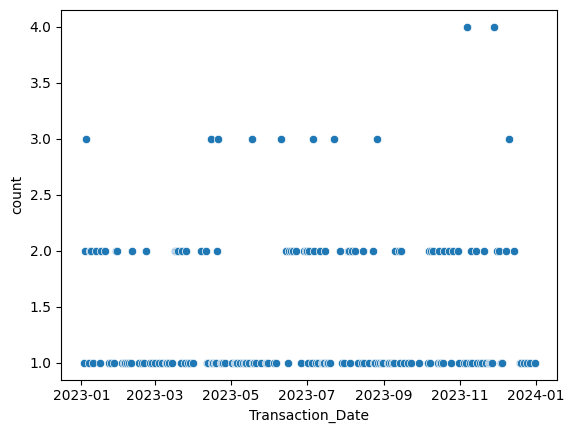

In [189]:
sns.scatterplot(df[df['Total_Spent']==25]['Transaction_Date'].value_counts().sort_index())

<Axes: ylabel='Total_Spent'>

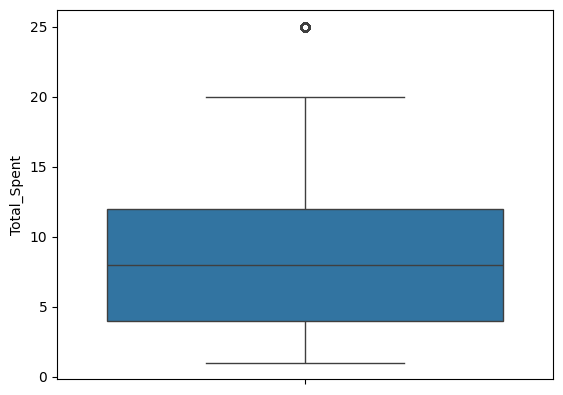

In [190]:
sns.boxplot(df['Total_Spent'])

### Data Transformation

In [191]:
df['Transaction_Date'].isnull().sum()

np.int64(0)

In [192]:
df['Transaction_Date']=pd.to_datetime(df['Transaction_Date'])
df['Transaction_Date']=df['Transaction_Date'].dt.strftime('%d-%b-%Y') #converting month number to name for ploting

##### adding a Day column for analysing throug weeks

In [193]:
df['Transaction_Date']=pd.to_datetime(df['Transaction_Date'], format='%d-%b-%Y')
df['Day'] = df['Transaction_Date'].dt.day_name()

In [194]:
df['weekend'] = np.where((df["Day"] == "Sunday") | (df["Day"] == "Saturday"), 1, 0)

In [195]:
df['Day'],df['weekend']

(0          Friday
 1         Tuesday
 2       Wednesday
 3        Thursday
 4          Sunday
           ...    
 9994       Sunday
 9995    Wednesday
 9997     Thursday
 9998     Saturday
 9999      Tuesday
 Name: Day, Length: 9926, dtype: object,
 0       0
 1       0
 2       0
 3       0
 4       1
        ..
 9994    1
 9995    0
 9997    0
 9998    1
 9999    0
 Name: weekend, Length: 9926, dtype: int64)

###Data visualization

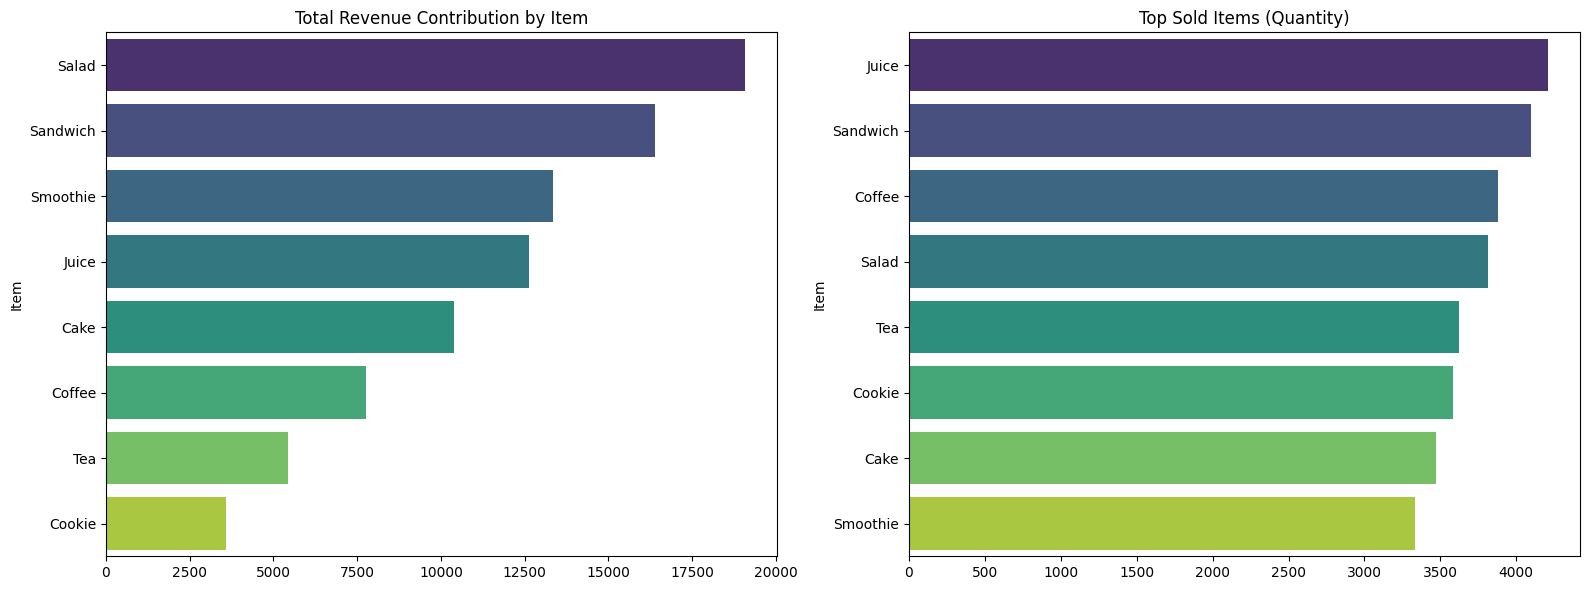

In [196]:
top_items_rev = df.groupby('Item')['Total_Spent'].sum().sort_values(ascending=False)# top revenue generated items
top_items_sold = df.groupby('Item')['Quantity'].sum().sort_values(ascending=False)# top sold items

f,ax=plt.subplots(1,2, figsize=(16,6))

sns.barplot(x=top_items_rev.values, y=top_items_rev.index, palette='viridis', ax=ax[0])
ax[0].set_title('Total Revenue Contribution by Item')

sns.barplot(x=top_items_sold.values, y=top_items_sold.index, palette='viridis', ax=ax[1])
ax[1].set_title('Top Sold Items (Quantity)')

plt.tight_layout() # Keeps things from overlapping
plt.show()


([<matplotlib.axis.YTick at 0x7a729c64e8d0>,
 [Text(0, 6000, '6000'), Text(0, 7000, '7000'), Text(0, 8000, '8000')])

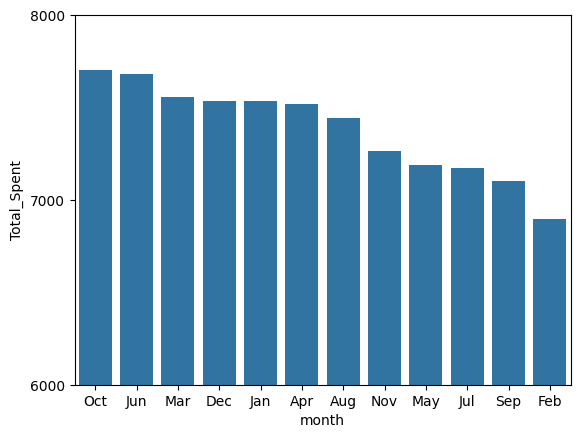

In [197]:
sns.barplot(df.groupby(['month'])['Total_Spent'].sum().sort_values(ascending=False))
plt.ylim(6000, 8000)             # This cuts off everything below 6000
plt.yticks([6000, 7000, 8000])

(2000.0, 2800.0)

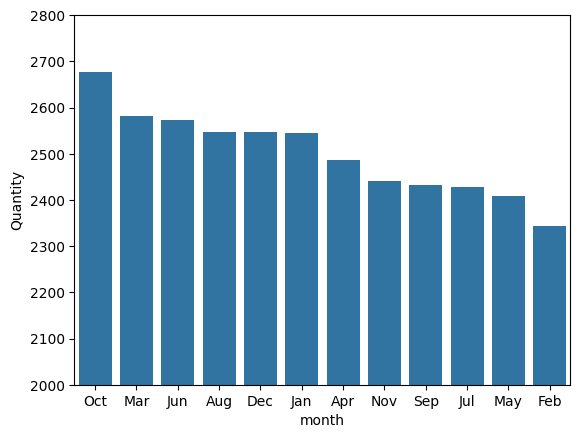

In [198]:
sns.barplot(df.groupby(['month'])['Quantity'].sum().sort_values(ascending=False))
plt.ylim(2000, 2800)
# plt.yticks()

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, '(2023-11-07 00:00:00, Tuesday)'),
  Text(1, 0, '(2023-07-24 00:00:00, Monday)'),
  Text(2, 0, '(2023-01-05 00:00:00, Thursday)'),
  Text(3, 0, '(2023-06-16 00:00:00, Friday)'),
  Text(4, 0, '(2023-04-30 00:00:00, Sunday)'),
  Text(5, 0, '(2023-06-30 00:00:00, Friday)'),
  Text(6, 0, '(2023-09-06 00:00:00, Wednesday)'),
  Text(7, 0, '(2023-01-12 00:00:00, Thursday)'),
  Text(8, 0, '(2023-10-19 00:00:00, Thursday)'),
  Text(9, 0, '(2023-08-26 00:00:00, Saturday)')])

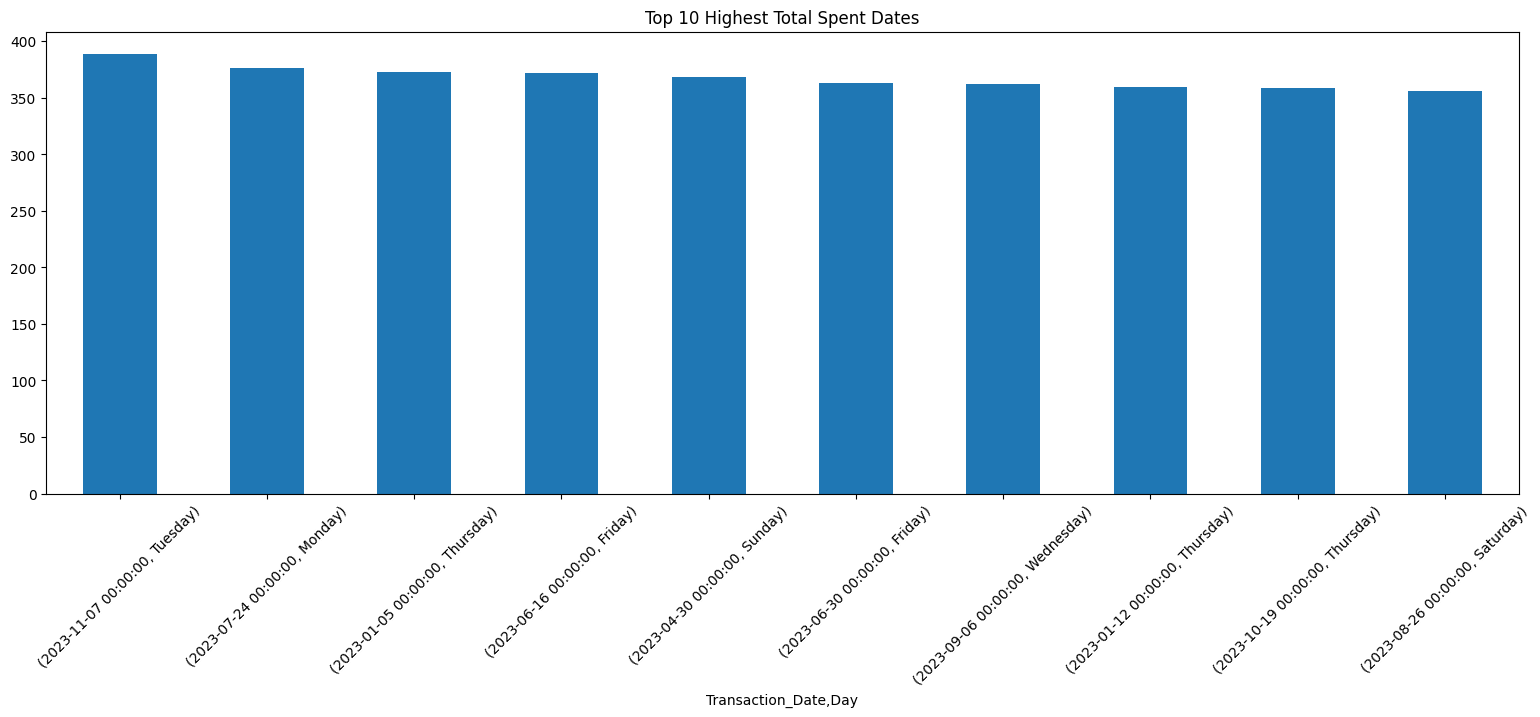

In [199]:
df.groupby(['Transaction_Date','Day'])['Total_Spent'].sum().nlargest(10).plot(kind='bar',figsize=(19,6))
plt.title('Top 10 Highest Total Spent Dates')
plt.xticks(rotation=45)

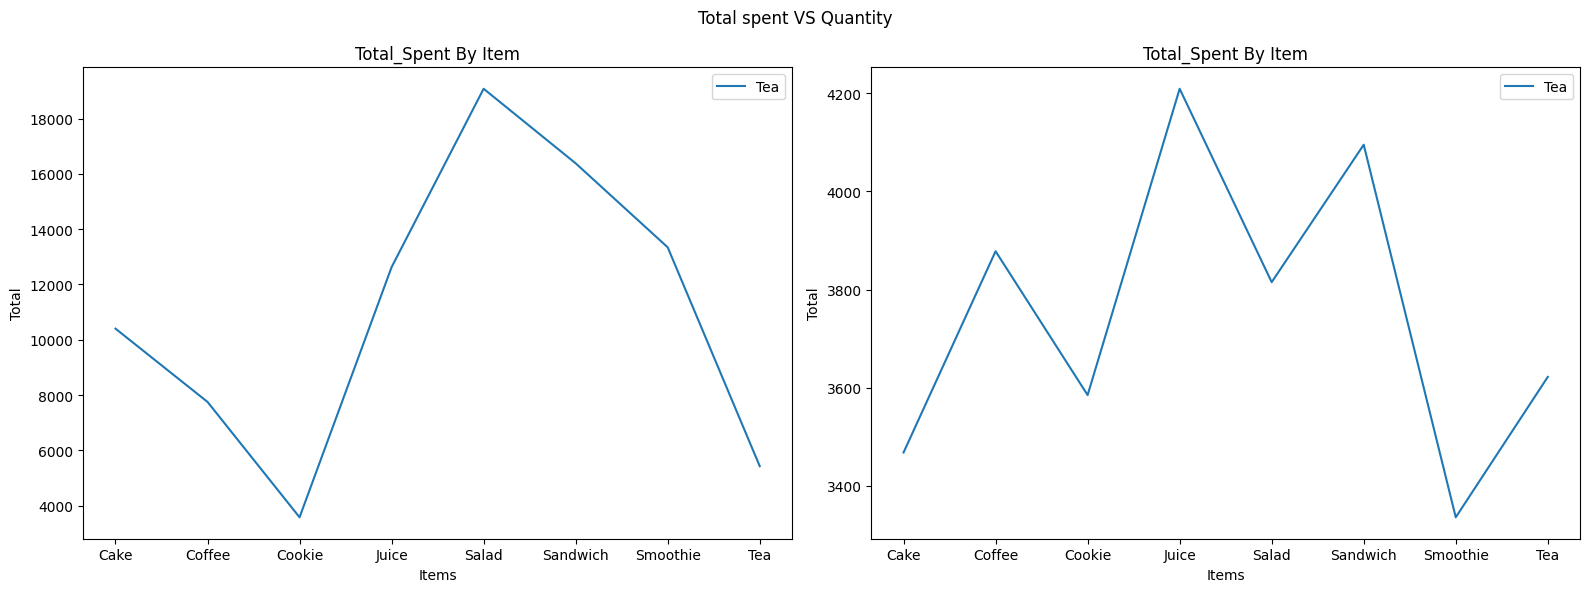

In [200]:
f,ax=plt.subplots(1,2, figsize=(16,6))

# First plot: Total Spent by Item

ax[0].plot(df.groupby('Item')['Total_Spent'].sum(), label=i)
ax[0].legend()
ax[0].set_title("Total_Spent By Item")
ax[0].set_xlabel("Items")
ax[0].set_ylabel("Total")

# Second plot: Sum of Quantity by Item

ax[1].plot(df.groupby('Item')['Quantity'].sum(), label=i)
ax[1].legend()
ax[1].set_title("Total_Spent By Item")
ax[1].set_xlabel("Items")
ax[1].set_ylabel("Total")
plt.suptitle("Total spent VS Quantity")
plt.tight_layout() # Adjust layout to prevent overlap
plt.show()

This Plot compares the **total revenue** (`Total_Spent`) and **total quantity sold** (`Quantity`) for each item in the cafe.


checking the total spent after removing the outliers

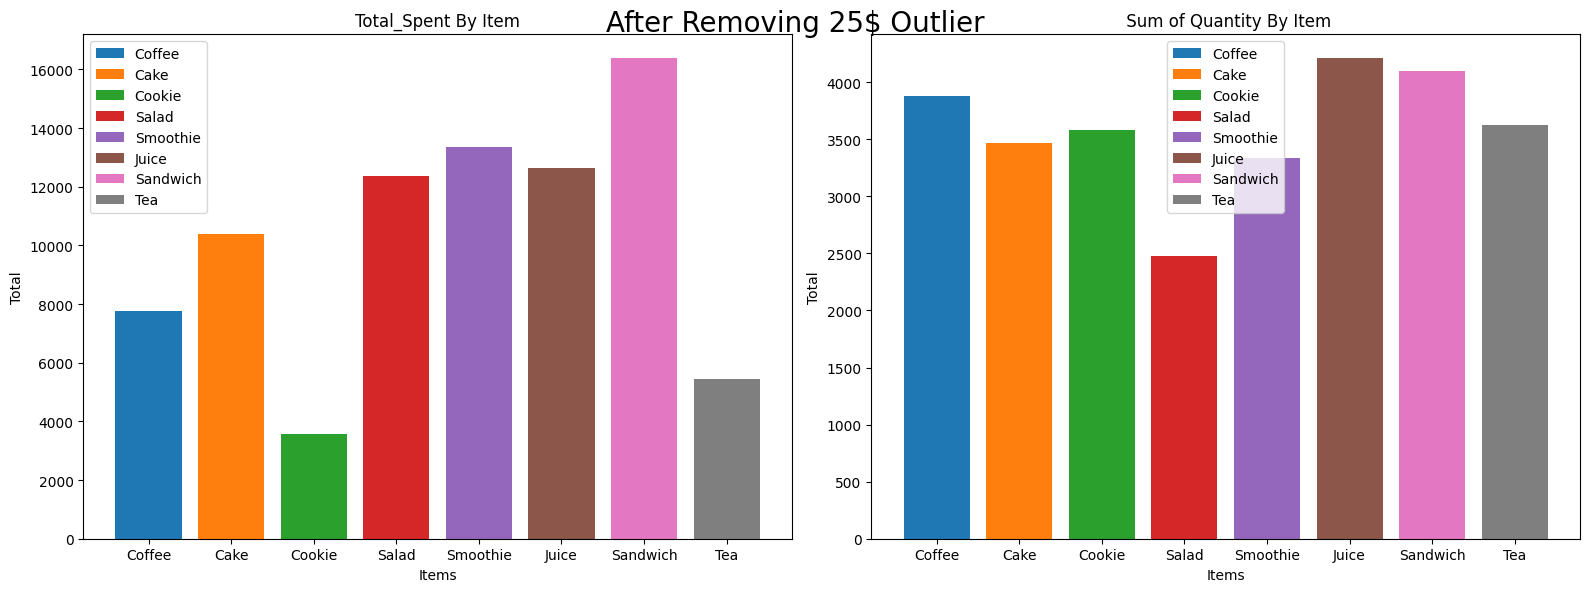

In [201]:
# Without 25$ spents
sample=df.drop(df[df['Total_Spent']==25].index)
f,ax=plt.subplots(1,2, figsize=(16,6))

# First plot: Total Spent by Item
for i in sample['Item'].unique().tolist():
  ax[0].bar(i, sample[sample['Item']==i]['Total_Spent'].sum(), label=i)
ax[0].legend()
ax[0].set_title("Total_Spent By Item")
ax[0].set_xlabel("Items")
ax[0].set_ylabel("Total")

# Second plot: Sum of Quantity by Item
for i in sample['Item'].unique().tolist():
  ax[1].bar(i, sample[sample['Item']==i]['Quantity'].sum(), label=i)
ax[1].legend()
ax[1].set_title(" Sum of Quantity By Item")
ax[1].set_xlabel("Items")
ax[1].set_ylabel("Total")

plt.tight_layout()
f.suptitle("After Removing 25$ Outlier", fontsize=20)
plt.show()

checking the location of

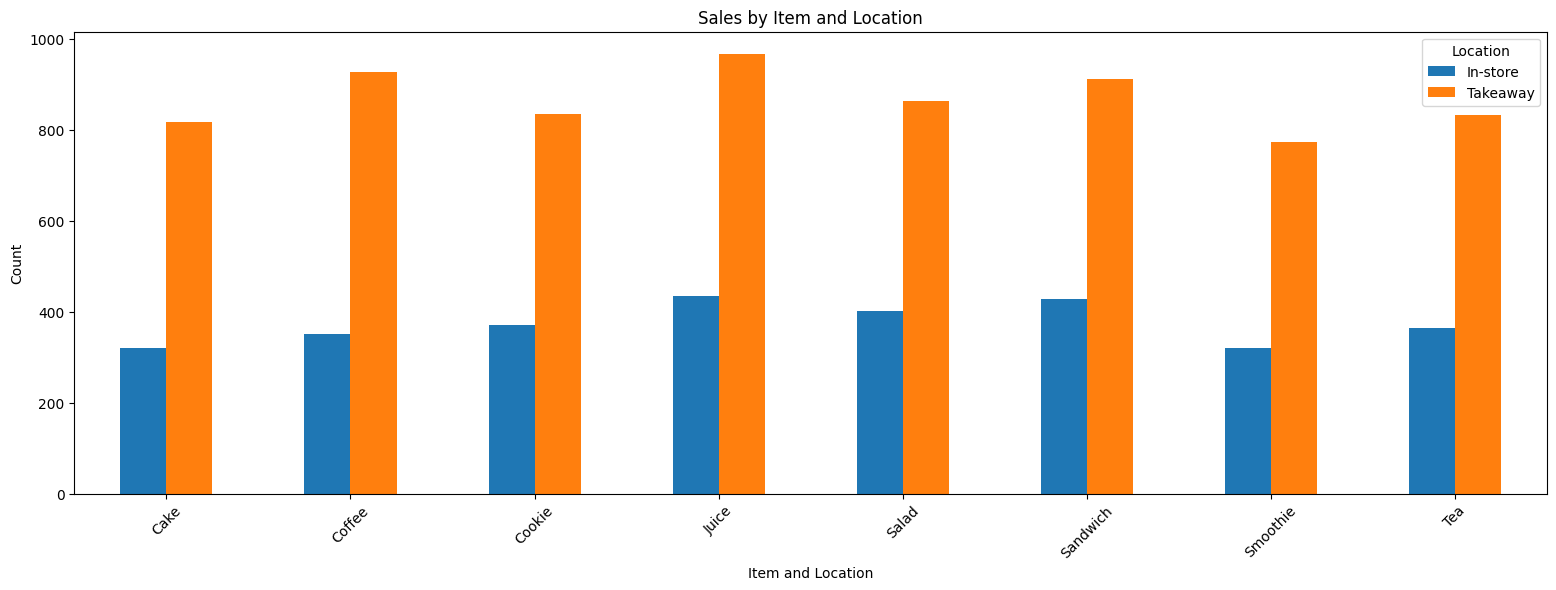

In [202]:
df.groupby(['Item', 'Location']).size().unstack().plot(kind='bar', figsize=(19, 6))
plt.xticks(rotation=45)
plt.title('Sales by Item and Location')
plt.xlabel('Item and Location')
plt.ylabel('Count')
plt.show()

#### Distribution of Total Spent

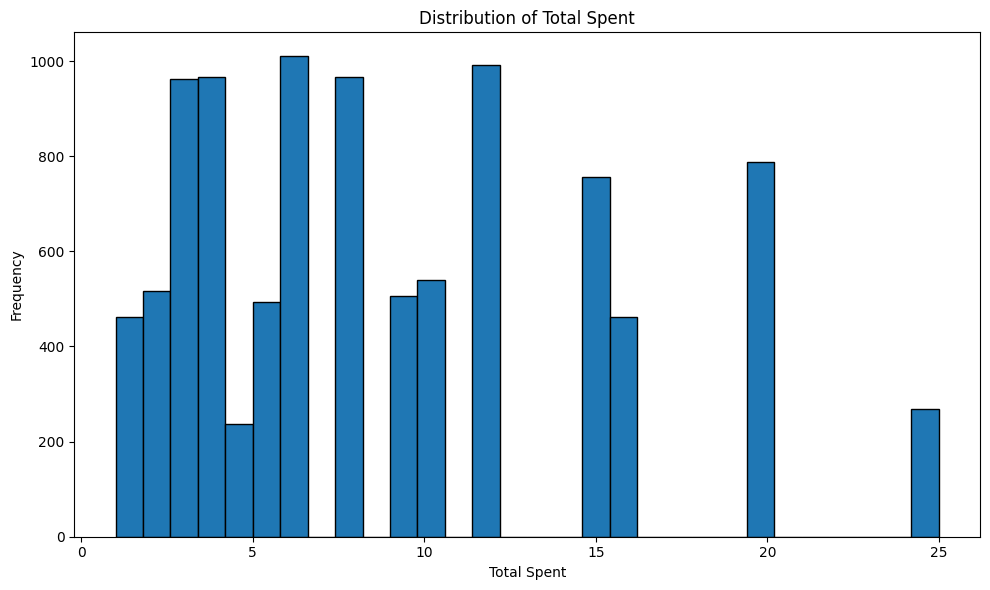

In [203]:
plt.figure(figsize=(10, 6))
plt.hist(df['Total_Spent'].dropna(), bins=30, edgecolor='black') # dropna() to handle missing values
plt.title('Distribution of Total Spent')
plt.xlabel('Total Spent')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [204]:
print(df['Total_Spent'].value_counts())

Total_Spent
6.0     1010
12.0     992
4.0      966
3.0      963
20.0     788
15.0     757
8.0      716
10.0     539
2.0      516
9.0      507
5.0      494
16.0     461
25.0     268
7.5      250
1.0      249
4.5      238
1.5      212
Name: count, dtype: int64


(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'Thursday'),
  Text(1, 0, 'Sunday'),
  Text(2, 0, 'Friday'),
  Text(3, 0, 'Monday'),
  Text(4, 0, 'Tuesday'),
  Text(5, 0, 'Saturday'),
  Text(6, 0, 'Wednesday')])

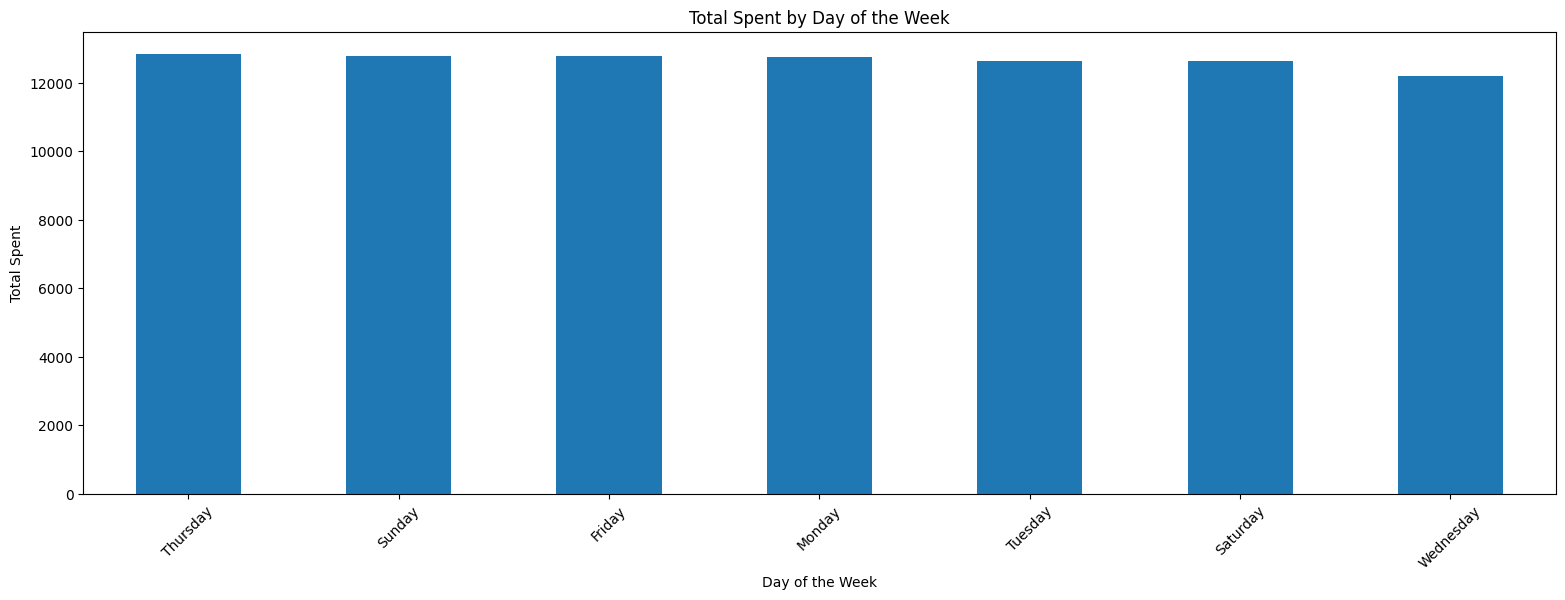

In [205]:
df.groupby('Day')['Total_Spent'].sum().sort_values(ascending=False).plot(kind='bar',figsize=(19,6))
plt.title('Total Spent by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Total Spent')
plt.xticks(rotation=45)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, '(2023-11-07 00:00:00, Tuesday, 25.0)'),
  Text(1, 0, '(2023-11-28 00:00:00, Tuesday, 25.0)'),
  Text(2, 0, '(2023-01-05 00:00:00, Thursday, 25.0)'),
  Text(3, 0, '(2023-04-15 00:00:00, Saturday, 25.0)'),
  Text(4, 0, '(2023-04-21 00:00:00, Friday, 25.0)'),
  Text(5, 0, '(2023-05-18 00:00:00, Thursday, 25.0)'),
  Text(6, 0, '(2023-06-10 00:00:00, Saturday, 25.0)'),
  Text(7, 0, '(2023-07-06 00:00:00, Thursday, 25.0)'),
  Text(8, 0, '(2023-07-23 00:00:00, Sunday, 25.0)'),
  Text(9, 0, '(2023-08-26 00:00:00, Saturday, 25.0)')])

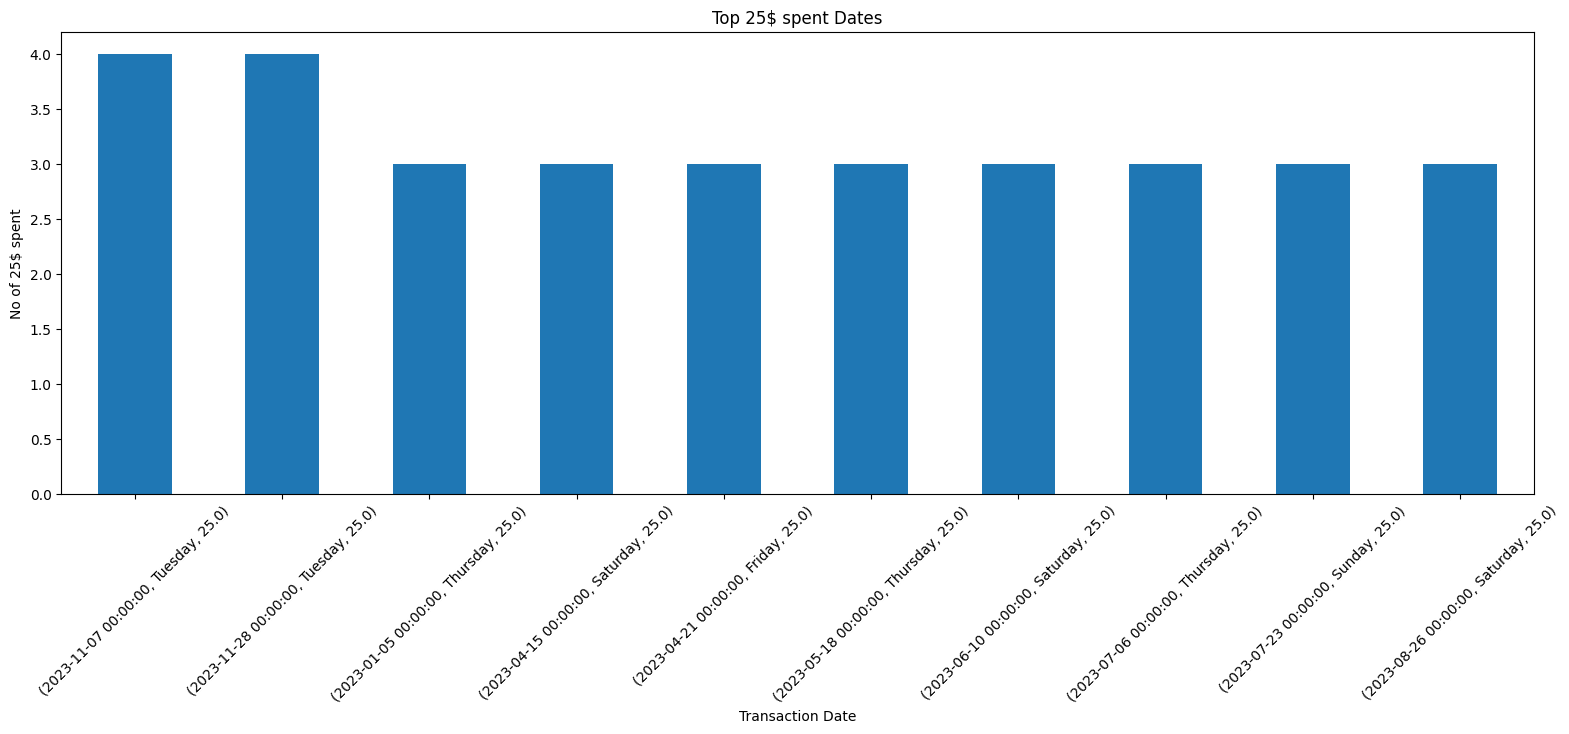

In [206]:
df[df['Total_Spent']==25].groupby(['Transaction_Date','Day'])['Total_Spent'].value_counts().nlargest(10).plot(kind='bar',figsize=(19,6))
plt.title('Top 25$ spent Dates')
plt.xlabel('Transaction Date')
plt.ylabel('No of 25$ spent')
plt.xticks(rotation=45)

<Axes: xlabel='Location'>

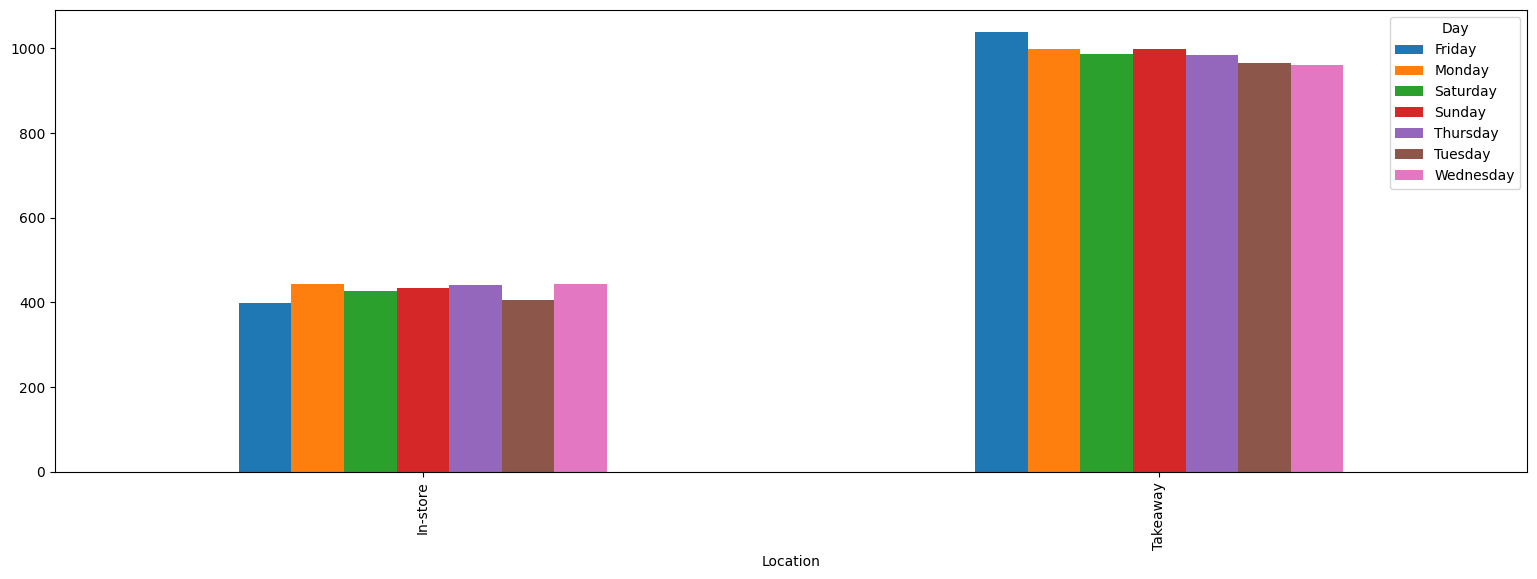

In [207]:
df.groupby('Location')['Day'].value_counts().unstack().plot(kind='bar',figsize=(19,6))


<Axes: ylabel='count'>

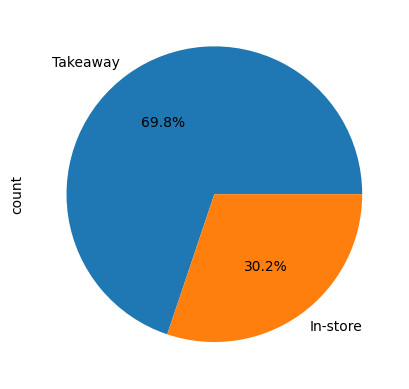

In [208]:
df['Location'].value_counts().plot(kind='pie',autopct='%1.1f%%')

Text(0.5, 1.0, 'Total spent on weekend')

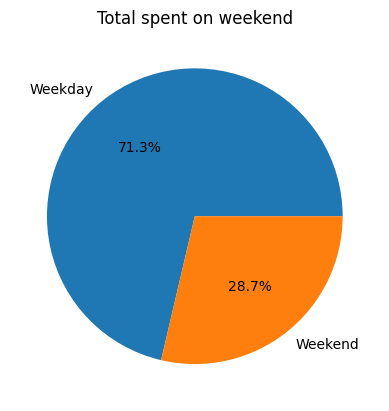

In [209]:
plt.pie(df.groupby('weekend')['Total_Spent'].sum(),autopct='%1.1f%%',labels=['Weekday','Weekend'])
plt.title("Total spent on weekend")

In [210]:
for i in df.Item.unique():
  a=df.groupby('Item')['weekend'].value_counts()[i][0]
  b=df.groupby('Item')['weekend'].value_counts()[i][1]
  print(f"{i}:\n {b/(a+b)*100 : .2f}% in Weekend")

Coffee:
  28.69% in Weekend
Cake:
  26.98% in Weekend
Cookie:
  29.99% in Weekend
Salad:
  28.79% in Weekend
Smoothie:
  27.33% in Weekend
Juice:
  28.17% in Weekend
Sandwich:
  31.49% in Weekend
Tea:
  27.55% in Weekend


In [211]:
df.groupby(['month','Item'])[['Total_Spent']].sum().unstack().reindex(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])




Total_Spent                                                       
Item         Cake Coffee Cookie   Juice   Salad Sandwich Smoothie    Tea
month                                                                   
Jan         882.0  616.0  299.0  1083.0  1750.0   1620.0    788.0  496.5
Feb         726.0  642.0  258.0  1008.0  1400.0   1364.0   1044.0  456.0
Mar         858.0  758.0  318.0  1128.0  1630.0   1364.0   1068.0  433.5
Apr         855.0  616.0  258.0  1179.0  1655.0   1348.0   1196.0  414.0
May         867.0  570.0  289.0  1050.0  1495.0   1436.0   1084.0  400.5
Jun         831.0  656.0  300.0  1101.0  1745.0   1428.0   1168.0  453.0
Jul         807.0  674.0  324.0   783.0  1775.0   1268.0   1112.0  429.0
Aug         855.0  662.0  314.0   990.0  1630.0   1356.0   1124.0  511.5
Sep         903.0  538.0  321.0   981.0  1345.0   1368.0   1184.0  462.0
Oct        1020.0  770.0  294.0  1179.0  1620.0   1128.0   1132.0  562.5
Nov        1014.0  568.0  316.0  1047.0  1595.0   1192.0   1160.0  370.5
Dec         786.0  686.0  294.0  1098.0  1435.0   1508.0   1284.0  444.0

In [212]:
df.groupby(['month','Item'])[['Quantity']].sum().unstack().reindex(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])




Quantity                                                     
Item      Cake Coffee Cookie  Juice  Salad Sandwich Smoothie    Tea
month                                                              
Jan      294.0  308.0  299.0  361.0  350.0    405.0    197.0  331.0
Feb      242.0  321.0  258.0  336.0  280.0    341.0    261.0  304.0
Mar      286.0  379.0  318.0  376.0  326.0    341.0    267.0  289.0
Apr      285.0  308.0  258.0  393.0  331.0    337.0    299.0  276.0
May      289.0  285.0  289.0  350.0  299.0    359.0    271.0  267.0
Jun      277.0  328.0  300.0  367.0  349.0    357.0    292.0  302.0
Jul      269.0  337.0  324.0  261.0  355.0    317.0    278.0  286.0
Aug      285.0  331.0  314.0  330.0  326.0    339.0    281.0  341.0
Sep      301.0  269.0  321.0  327.0  269.0    342.0    296.0  308.0
Oct      340.0  385.0  294.0  393.0  324.0    282.0    283.0  375.0
Nov      338.0  284.0  316.0  349.0  319.0    298.0    290.0  247.0
Dec      262.0  343.0  294.0  366.0  287.0    377.0    321.0  296.0

In [213]:
df.groupby(['Quarter','Item'])['Total_Spent'].sum().unstack()

Item,Cake,Coffee,Cookie,Juice,Salad,Sandwich,Smoothie,Tea
Quarter,,,,,,,,
Q1,2466.0,2016.0,875.0,3219.0,4780.0,4348.0,2900.0,1386.0
Q2,2553.0,1842.0,847.0,3330.0,4895.0,4212.0,3448.0,1267.5
Q3,2565.0,1874.0,959.0,2754.0,4750.0,3992.0,3420.0,1402.5
Q4,2820.0,2024.0,904.0,3324.0,4650.0,3828.0,3576.0,1377.0


In [214]:
# high revenue in each month
df.groupby(['month','Item'])['Total_Spent'].sum().groupby(level=0).nlargest(1)

,,,Total_Spent
month,month,Item,
Apr,Apr,Salad,1655.0
Aug,Aug,Salad,1630.0
Dec,Dec,Sandwich,1508.0
Feb,Feb,Salad,1400.0
Jan,Jan,Salad,1750.0
Jul,Jul,Salad,1775.0
Jun,Jun,Salad,1745.0
Mar,Mar,Salad,1630.0
May,May,Salad,1495.0


In [215]:
# highest sold item in each month
df.groupby(['month','Item'])['Quantity'].sum().groupby(level=0).nlargest(1)

,,,Quantity
month,month,Item,
Apr,Apr,Juice,393.0
Aug,Aug,Tea,341.0
Dec,Dec,Sandwich,377.0
Feb,Feb,Sandwich,341.0
Jan,Jan,Sandwich,405.0
Jul,Jul,Salad,355.0
Jun,Jun,Juice,367.0
Mar,Mar,Coffee,379.0
May,May,Sandwich,359.0


In [216]:
df.groupby('month')['Transaction_ID'].nunique().reindex(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

,Transaction_ID
month,
Jan,848
Feb,763
Mar,865
Apr,807
May,798
Jun,851
Jul,817
Aug,841
Sep,808


In [217]:
df.groupby('month')['Total_Spent'].mean().reindex(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

,Total_Spent
month,
Jan,8.885023
Feb,9.040629
Mar,8.736994
Apr,9.319702
May,9.011905
Jun,9.027027
Jul,8.778458
Aug,8.849584
Sep,8.789604


In [218]:
df.to_excel('data.xlsx', index=False)

## Conclusion


From the analysis, I found the following insights:

* Salad is the highest revenue-generating item.
* Juice is the most sold item.
* February recorded the lowest sales.
* Highest total spent is 25$
* Around 69% of customers preferred takeaway orders.
* 54% of the trascations are digital wallet

This project helped me strengthen my skills in:
* Data cleaning
* Handling missing values
* Data transformation
* Exploratory Data Analysis
* Data visualization using Python libraries like Pandas and Matplotlib